# Imputacion Basica De Datos

Remplazar los valores por algun valor como:

- Estadistico basado en los datos que si tenemos 
- Valores que tenemos basados en el contexto
- Modelos predictivos a base del Machine Learning 

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import janitor as jn

from src.pandas_accessors import MissingMethods
from src.data_loader import load_all_datasets

datasets = load_all_datasets()

riskfactors =datasets['riskfactors']

## Imputacion con base en el contexto

En este caso en la columna name deberia repetirse el nombre tanto en morning como en afternoon

Entonces es lo que haremos a continuacion rellenar los NaN con los nombres de las personas a quien pertenece basado en el contexto que se infiere

Al aplicar `ffill()` queremos decir foward fill por lo que se rellenara el valor faltante con el que esta arriba

In [2]:
implicit_to_explicit_data = pd.DataFrame(
    data={
        "name": ["lynn", np.nan, "zelda", np.nan, "shadowsong", np.nan],
        "time": ["morning", "afternoon", "morning", "afternoon", "morning", "afternoon"],
        "value": [350, 310, 320, 350, 310, 320]
    }
)

implicit_to_explicit_data

,name,time,value
0,lynn,morning,350
1,NaN,afternoon,310
2,zelda,morning,320
3,NaN,afternoon,350
4,shadowsong,morning,310
5,NaN,afternoon,320


In [3]:
implicit_to_explicit_data.ffill()

,name,time,value
0,lynn,morning,350
1,lynn,afternoon,310
2,zelda,morning,320
3,zelda,afternoon,350
4,shadowsong,morning,310
5,shadowsong,afternoon,320


## Imputacion de un unico valor

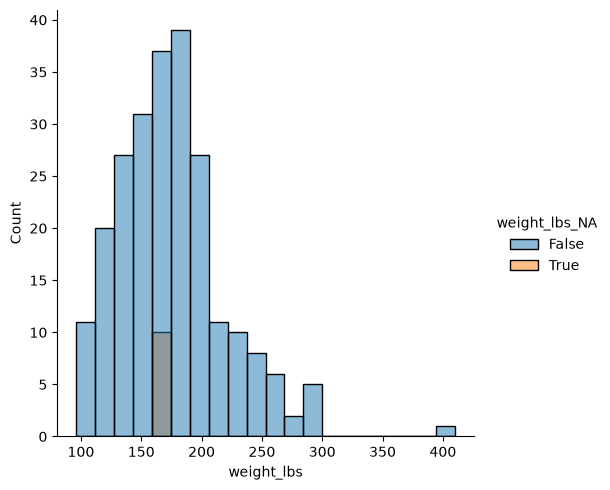

In [11]:
(
    riskfactors
    .select_columns("weight_lbs", "height_inch", "bmi")
    .missing.bind_shadow_matrix(true_string=True, false_string=False)
    .apply(
        axis= "rows",
        func = lambda column : column.fillna(column.mean()) if "_NA" not in column.name else column
    )
    .pipe(
        lambda df: (
            sns.displot(
                data=df,
                x="weight_lbs",
                hue="weight_lbs_NA",
            )
        )
    )
)

<Axes: xlabel='weight_lbs', ylabel='height_inch'>

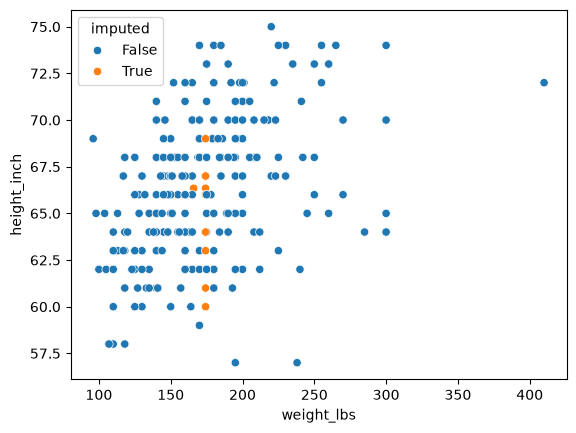

In [14]:
(
    riskfactors
    .select_columns("weight_lbs", "height_inch", "bmi")
    .missing.bind_shadow_matrix(true_string=True, false_string=False)
    .apply(
        axis= "rows",
        func = lambda column : column.fillna(column.mean()) if "_NA" not in column.name else column
    )
    .assign(
        imputed = lambda df: df.weight_lbs_NA | df.height_inch_NA
    )
    .pipe(
        lambda df: (
            sns.scatterplot(
                data=df,
                x="weight_lbs",
                y="height_inch",
                hue="imputed"
            )
        )
    )
)

## Visualizacion de multiples variables

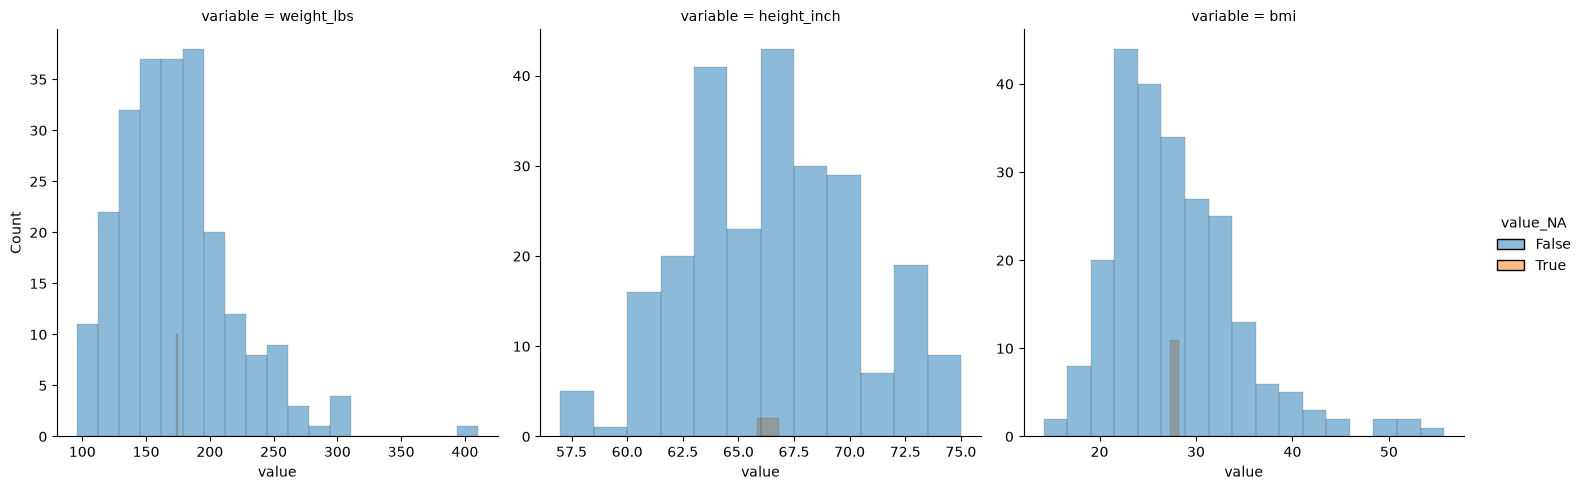

In [31]:
(
    riskfactors
    .select_columns("weight_lbs", "height_inch", "bmi")
    .missing.bind_shadow_matrix(true_string=True, false_string=False)
    .apply(
        axis="rows",
        func=lambda column: (
            column.fillna(column.mean())
            if "_NA" not in column.name
            else column
        )
    )
    .pivot_longer(
        index="*_NA"
    )
    .pivot_longer(
        index=["variable", "value"],
        names_to="variable_NA",
        values_to="value_NA"
    )
    .assign(
        valid= lambda df: df.apply(
            axis="columns",
            func= lambda column: column.variable in column.variable_NA 
        )
    )
    .query("valid")
    .pipe(
        lambda df: (
            sns.displot(
                data=df,
                x="value",
                hue="value_NA",
                col="variable",
                common_bins=False,
                facet_kws={"sharex": False, "sharey": False},
            )
        )
    )
)


### ***Visualización de múltiples imputaciones***

> ***En una frase:*** El código crea una matriz de valores faltantes, imputa los `NaN` con la media y reorganiza los datos para comparar valores observados e imputados.

---

### ***1. DataFrame original***

Partimos de:

| weight_lbs | height_inch | bmi |
|---:|---:|---:|
| 190 | 66 | 27.8 |
| NaN | 64 | 30.1 |
| 163 | NaN | NaN |

---

### ***2. Selección de variables***

```python
.select_columns(
    "weight_lbs",
    "height_inch",
    "bmi"
)
```

Selecciona únicamente las tres variables que serán analizadas.

---

### ***3. Shadow Matrix***

```python
.missing.bind_shadow_matrix(
    true_string=True,
    false_string=False
)
```

Crea una columna `_NA` para cada variable, indicando si el valor original estaba faltante.

| weight_lbs | height_inch | bmi | weight_lbs_NA | height_inch_NA | bmi_NA |
|---:|---:|---:|---|---|---|
| 190 | 66 | 27.8 | False | False | False |
| NaN | 64 | 30.1 | True | False | False |
| 163 | NaN | NaN | False | True | True |

- `True` → originalmente faltante.
- `False` → originalmente presente.

---

### ***4. Imputación***

```python
.apply(
    axis="rows",
    func=lambda column: (
        column.fillna(column.mean())
        if "_NA" not in column.name
        else column
    )
)
```

Los `NaN` de las variables originales se reemplazan por la media. Las columnas `_NA` permanecen intactas.

| weight_lbs | height_inch | bmi | weight_lbs_NA | height_inch_NA | bmi_NA |
|---:|---:|---:|---|---|---|
| 190 | 66 | 27.8 | False | False | False |
| 176.5 | 64 | 30.1 | True | False | False |
| 163 | 65 | 28.95 | False | True | True |

Por ejemplo, `176.5` fue imputado, pero `weight_lbs_NA` continúa siendo `True`.

---

### ***5. Primer `pivot_longer()`***

```python
.pivot_longer(
    index="*_NA"
)
```

Mantiene las columnas `_NA` y convierte las variables originales en filas.

| weight_lbs_NA | height_inch_NA | bmi_NA | variable | value |
|---|---|---|---|---:|
| False | False | False | weight_lbs | 190 |
| False | False | False | height_inch | 66 |
| False | False | False | bmi | 27.8 |
| True | False | False | weight_lbs | 176.5 |
| False | True | True | height_inch | 65 |
| False | True | True | bmi | 28.95 |

`variable` contiene el nombre de la variable y `value` contiene su valor.

---

### ***6. Segundo `pivot_longer()`***

```python
.pivot_longer(
    index=["variable", "value"],
    names_to="variable_NA",
    values_to="value_NA"
)
```

Convierte las columnas `_NA` restantes en filas.

| variable | value | variable_NA | value_NA |
|---|---:|---|---|
| weight_lbs | 190 | weight_lbs_NA | False |
| weight_lbs | 190 | height_inch_NA | False |
| weight_lbs | 190 | bmi_NA | False |
| height_inch | 66 | height_inch_NA | False |
| bmi | 27.8 | bmi_NA | False |
| weight_lbs | 176.5 | weight_lbs_NA | True |

- `variable_NA` → nombre del indicador `_NA`.
- `value_NA` → indica si el valor era originalmente faltante.

---

### ***7. Crear `valid`***

```python
.assign(
    valid=lambda df: df.apply(
        axis="columns",
        func=lambda column: (
            column.variable in column.variable_NA
        )
    )
)
```

Comprueba que cada variable esté relacionada con su propio indicador.

| variable | variable_NA | valid |
|---|---|---|
| weight_lbs | weight_lbs_NA | True |
| weight_lbs | height_inch_NA | False |
| height_inch | height_inch_NA | True |
| bmi | bmi_NA | True |

Por ejemplo:

```text
weight_lbs → weight_lbs_NA → True
height_inch → height_inch_NA → True
bmi → bmi_NA → True
```

---

### ***8. Filtrar***

```python
.query("valid")
```

Conserva únicamente las relaciones correctas.

| variable | value | variable_NA | value_NA |
|---|---:|---|---|
| weight_lbs | 190 | weight_lbs_NA | False |
| weight_lbs | 176.5 | weight_lbs_NA | True |
| height_inch | 66 | height_inch_NA | False |
| height_inch | 65 | height_inch_NA | True |
| bmi | 27.8 | bmi_NA | False |
| bmi | 28.95 | bmi_NA | True |

Ahora cada valor está relacionado con su propio indicador de ausencia.

---

### ***9. Visualización***

```python
.pipe(
    lambda df: (
        sns.displot(
            data=df,
            x="value",
            hue="value_NA",
            col="variable",
            common_bins=False,
            facet_kws={
                "sharex": False,
                "sharey": False
            },
        )
    )
)
```

| Parámetro | Función |
|---|---|
| `x="value"` | Representa los valores numéricos. |
| `hue="value_NA"` | Diferencia observados e imputados. |
| `col="variable"` | Crea un gráfico por variable. |
| `common_bins=False` | Usa intervalos independientes. |
| `sharex=False` | Cada gráfico tiene su propia escala X. |
| `sharey=False` | Cada gráfico tiene su propia escala Y. |

---

### ***10. Flujo del código***

```text
DataFrame original
        ↓
select_columns()
        ↓
Shadow Matrix
        ↓
Imputación con la media
        ↓
pivot_longer(index="*_NA")
        ↓
variable + value
        ↓
pivot_longer()
        ↓
variable_NA + value_NA
        ↓
assign(valid)
        ↓
query("valid")
        ↓
sns.displot()
```

### ***Idea fundamental***

`value_NA` permite distinguir entre:

| value_NA | Significado |
|---|---|
| `False` | Valor originalmente observado. |
| `True` | Valor originalmente faltante e imputado. |

Por tanto, la gráfica final permite comparar la distribución de los **valores observados frente a los valores imputados** para `weight_lbs`, `height_inch` y `bmi`.
